# Initial set ups

In [ ]:
import pandas as pd
import numpy as np
import os
import glob

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE

# install xgboost if not present
!pip install xgboost
from xgboost import XGBClassifier

### Custom Data Loading Function

# Data Extraction

In [ ]:
def load_dataset(folder_path):
    # Support both CSV and Parquet formats
    all_files = glob.glob(os.path.join(folder_path, "*"))

    df_list = []
    for file in all_files:
        try:
            if file.endswith(".parquet"):
                df = pd.read_parquet(file)
                df_list.append(df)
            elif file.endswith(".csv"):
                df = pd.read_csv(file)
                df_list.append(df)
        except Exception as e:
            print(f"Error loading {file}: {e}")

    if not df_list:
        return pd.DataFrame()
    combined_df = pd.concat(df_list, ignore_index=True)
    return combined_df

### Mount Google Drive

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
print("Google Drive mount bypassed for local execution.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Load CICIDS Dataset

In [ ]:
cicids = load_dataset("data/CIC-IDS-2017/CIC-IDS-2017")

### Load CICIOT Dataset

In [ ]:
# ciciot = load_dataset("data/CICIOT2023")
print("CICIOT load bypassed (unused in notebook)")

### Load UNSW Dataset

In [ ]:
unsw = pd.read_parquet("data/Kaggle-UNSW-NB15-V2/Kaggle-UNSW-NB15-V2/NF-UNSW-NB15-V2.parquet")

Error loading /content/drive/MyDrive/4thSemELDatasets/UNSW-NB15/NUSW-NB15_features.csv


/tmp/ipykernel_1836/3670526034.py:7: DtypeWarning: Columns (1,3,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)
/tmp/ipykernel_1836/3670526034.py:7: DtypeWarning: Columns (3,39,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


### Check Dataset Shapes

In [ ]:
print("CICIDS:", cicids.shape)
print("UNSW:", unsw.shape)

CICIDS: (2830743, 79)
UNSW: (2714390, 151)


### Sample Datasets

In [ ]:
cicids = cicids.sample(n=200000, random_state=42)
unsw = unsw.sample(n=200000, random_state=42)

### Verify Sampled Shapes

In [ ]:
print(cicids.shape, unsw.shape)

(200000, 79) (200000, 151)


### Identify Label Columns

#Data cleaning

cicids

In [ ]:
for df, name in [(cicids, "CICIDS"), (unsw, "UNSW")]:
    print(f"\n{name} label candidates:")
    for col in df.columns:
        if "label" in col.lower() or "attack" in col.lower():
            print(col)


CICIDS label candidates:
 Label

UNSW label candidates:
Attack category
Attack subcategory
Attack Name
Attack Reference


### Display CICIDS Columns

In [ ]:
print(cicids.columns.tolist())

[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag 

### Strip CICIDS Column Names

In [ ]:
cicids.columns = cicids.columns.str.strip()
print(cicids.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

### Clean & Binarize CICIDS Labels

In [ ]:
cicids['Label'] = cicids['Label'].astype(str).str.lower()

cicids['Label'] = cicids['Label'].apply(
    lambda x: 0 if x == "benign" else 1
)

### Check CICIDS Label Distribution

In [ ]:
print(cicids['Label'].value_counts())

Label
0    160550
1     39450
Name: count, dtype: int64


### Initial UNSW Label Counts

UNSW

In [ ]:
print(unsw['Attack'].value_counts().head(20))

Attack category
Exploits            5032
 Fuzzers            2172
DoS                 1829
Generic             1434
 Reconnaissance     1312
Backdoor             301
 Fuzzers             299
Analysis             152
Reconnaissance       143
 Shellcode           100
Worms                 14
Backdoors             13
Shellcode             12
Name: count, dtype: int64


### Strip UNSW Column Names

In [ ]:
unsw.columns = unsw.columns.str.strip()

### Clean UNSW Attack Category

In [ ]:
unsw['Attack'] = unsw['Attack'].astype(str).str.strip()

### Cleaned UNSW Label Counts

In [ ]:
print(unsw['Attack'].value_counts().head(20))

Attack category
nan               187187
Exploits            5032
Fuzzers             2471
DoS                 1829
Reconnaissance      1455
Generic             1434
Backdoor             301
Analysis             152
Shellcode            112
Worms                 14
Backdoors             13
Name: count, dtype: int64


### Binarize UNSW Labels

In [ ]:
# In local NF-UNSW-NB15-v2, the 'Label' column is already 0 (Benign) and 1 (Attack)
unsw['Attack category'] = unsw['Label']

### Check Binarized UNSW Label Distribution

In [ ]:
print(unsw['Attack category'].value_counts())

Attack category
0    187187
1     12813
Name: count, dtype: int64


### Rename Label Columns

In [ ]:
unsw = unsw.rename(columns={"Attack category": "label"})
cicids = cicids.rename(columns={"Label": "label"})

### Final Label Distribution Check

In [ ]:
print("CICIDS:\n", cicids['label'].value_counts())
print("\nUNSW:\n", unsw['label'].value_counts())

CICIDS:
 label
0    160550
1     39450
Name: count, dtype: int64

UNSW:
 label
0    187187
1     12813
Name: count, dtype: int64


### Find Common Columns

Feature Selection

In [ ]:
common_cols = list(set(cicids.columns) & set(unsw.columns))
print("Number of common columns:", len(common_cols))
print(common_cols[:20])  # preview

Number of common columns: 2
['label', 'Destination Port']


### Check 'label' in Common Columns

In [ ]:
print("label in common_cols:", 'label' in common_cols)

label in common_cols: True


### Split Features and Target (CICIDS)

#Training model seperatly then common predition

CICIDS

In [ ]:
X = cicids.drop("label", axis=1)
y = cicids["label"]

### Split Train/Test Data

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Clean Infinities and NaNs BEFORE running SMOTE to prevent ValueError
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.dropna()
y_train = y_train[X_train.index]

X_test = X_test.dropna()
y_test = y_test[X_test.index]

### Apply SMOTE (Initial Attempt)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

### Check for NaNs before SMOTE

fixing

In [ ]:
print(X_train.isna().sum().sum())

75


### Handle NaNs and Infs

In [ ]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.dropna()
y_train = y_train[X_train.index]

X_test = X_test.dropna()
y_test = y_test[X_test.index]

### Re-check NaNs

In [ ]:
print(X_train.isna().sum().sum())

0


### Apply SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

### Train Decision Tree Model

Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9978981608907794
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     32205
           1       0.99      1.00      0.99      7760

    accuracy                           1.00     39965
   macro avg       1.00      1.00      1.00     39965
weighted avg       1.00      1.00      1.00     39965



### Plot Confusion Matrix

visualization

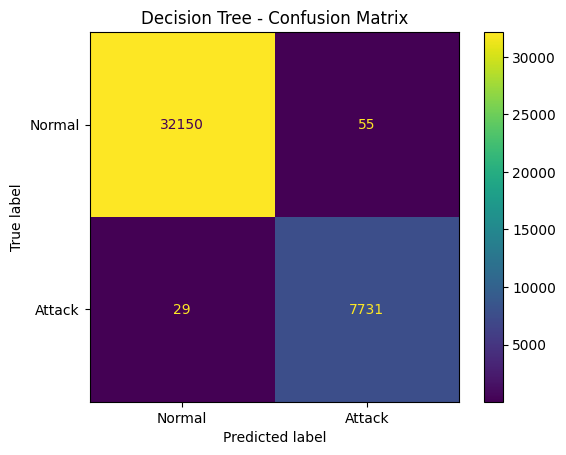

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"])
disp.plot()

plt.title("Decision Tree - Confusion Matrix")
plt.show()

### Plot Accuracy Score

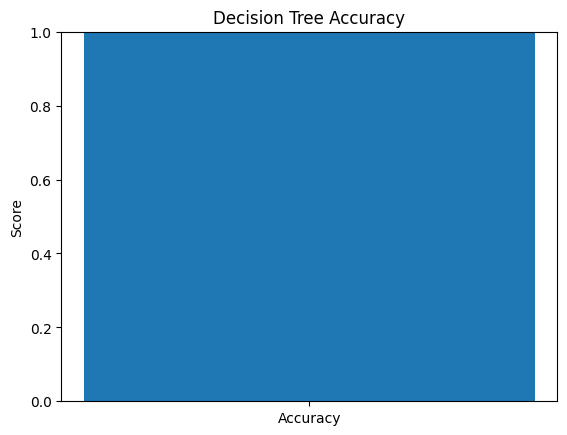

In [ ]:
import matplotlib.pyplot as plt

labels = ['Accuracy']
values = [0.9979]  # your accuracy

plt.figure()
plt.bar(labels, values)
plt.title("Decision Tree Accuracy")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.show()

### Plot Performance Metrics

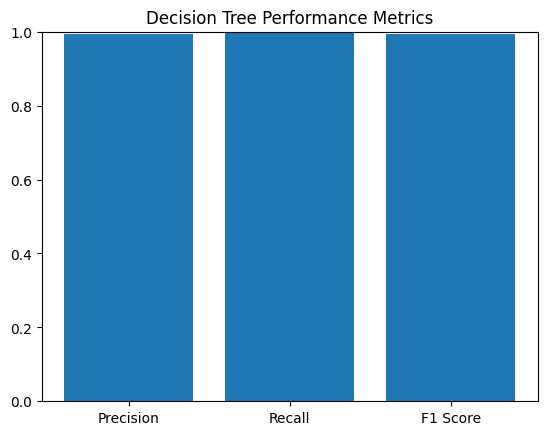

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)

metrics = ['Precision', 'Recall', 'F1 Score']
values = [precision, recall, f1]

plt.figure()
plt.bar(metrics, values)
plt.title("Decision Tree Performance Metrics")
plt.ylim(0, 1)
plt.show()

### Plot Decision Tree

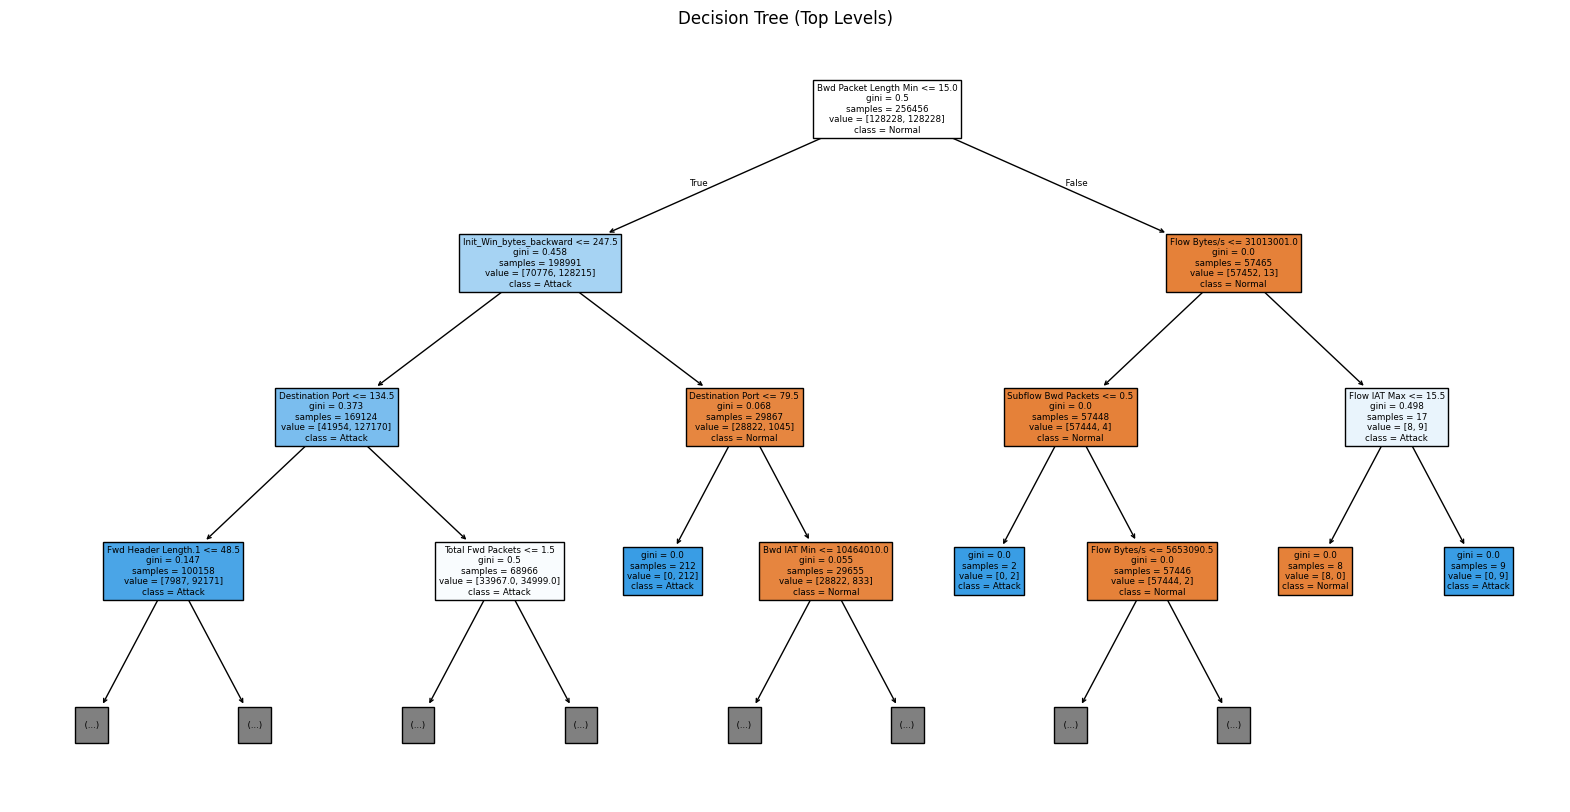

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dt, max_depth=3, feature_names=X.columns, class_names=["Normal", "Attack"], filled=True)
plt.title("Decision Tree (Top Levels)")
plt.show()

### Train Random Forest (Initial)

random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9982234455148254
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     32205
           1       1.00      1.00      1.00      7760

    accuracy                           1.00     39965
   macro avg       1.00      1.00      1.00     39965
weighted avg       1.00      1.00      1.00     39965



### Plot Confusion Matrix

visualization

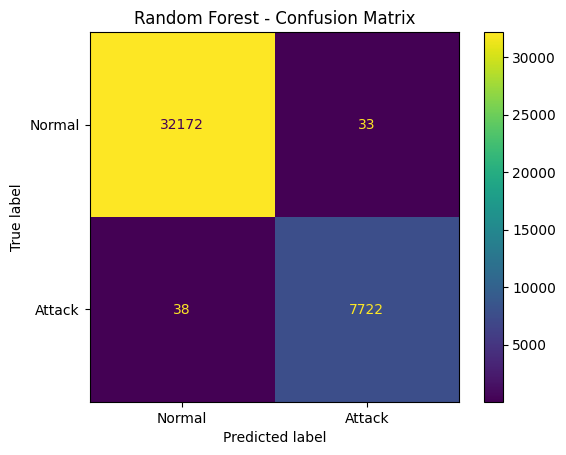

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Normal", "Attack"])
disp.plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

### Plot Performance Metrics

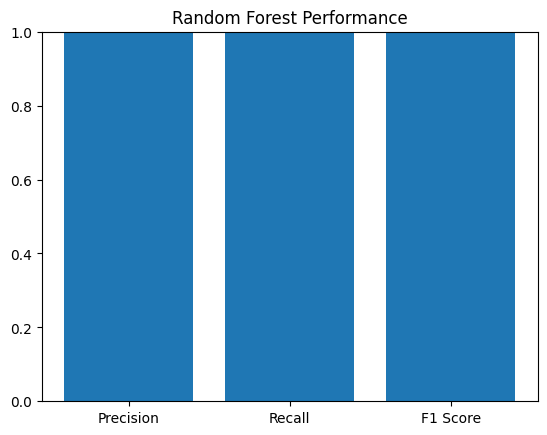

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

metrics = ['Precision', 'Recall', 'F1 Score']
values = [precision, recall, f1]

plt.figure()
plt.bar(metrics, values)
plt.title("Random Forest Performance")
plt.ylim(0, 1)
plt.show()

### Plot Feature Importances

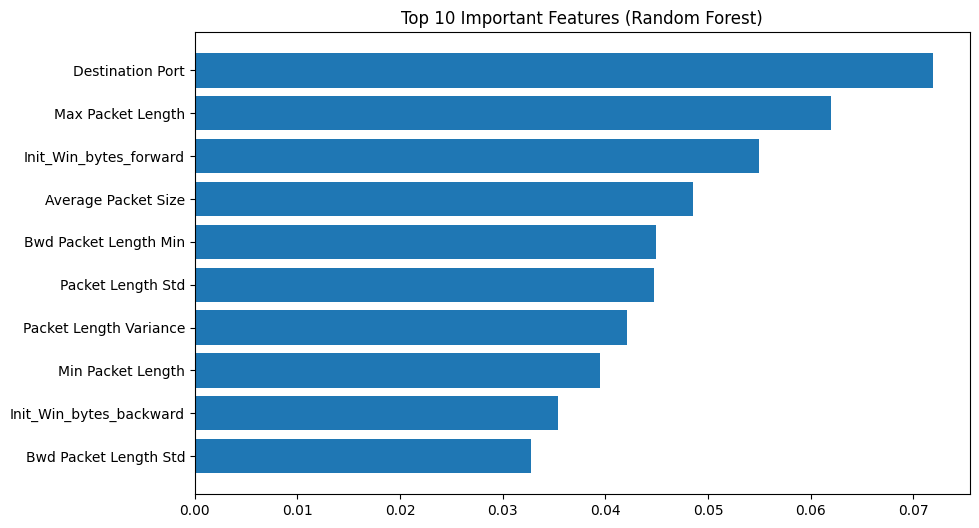

In [ ]:
import pandas as pd

importances = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_df["Feature"][:10], feat_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features (Random Forest)")
plt.show()

### Train Random Forest (Tuned)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    max_features='sqrt',
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Fixed RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Fixed RF Accuracy: 0.998448642562242
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     32205
           1       1.00      1.00      1.00      7760

    accuracy                           1.00     39965
   macro avg       1.00      1.00      1.00     39965
weighted avg       1.00      1.00      1.00     39965



### Display Top Features

In [ ]:
import pandas as pd

feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feat_df.head(10))

                    Feature  Importance
0          Destination Port    0.062304
66   Init_Win_bytes_forward    0.061352
39        Max Packet Length    0.059550
42   Packet Length Variance    0.051541
52      Average Packet Size    0.047506
41        Packet Length Std    0.047253
38        Min Packet Length    0.040820
11    Bwd Packet Length Min    0.040055
67  Init_Win_bytes_backward    0.038110
63        Subflow Fwd Bytes    0.032829


### Train XGBoost Classifier

XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9989991242337045
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     32205
           1       1.00      1.00      1.00      7760

    accuracy                           1.00     39965
   macro avg       1.00      1.00      1.00     39965
weighted avg       1.00      1.00      1.00     39965



### Plot Confusion Matrix

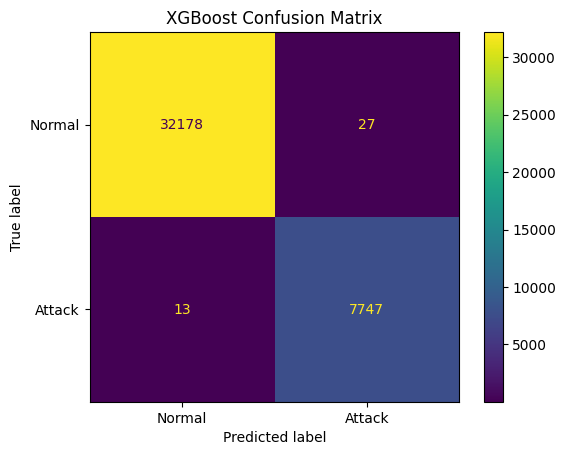

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Attack"])
disp.plot()

plt.title("XGBoost Confusion Matrix")
plt.show()

### Plot Feature Importances

11      Bwd Packet Length Min
2           Total Fwd Packets
52        Average Packet Size
55        Fwd Header Length.1
67    Init_Win_bytes_backward
42     Packet Length Variance
35          Bwd Header Length
13      Bwd Packet Length Std
9       Fwd Packet Length Std
47             ACK Flag Count
Name: Feature, dtype: object


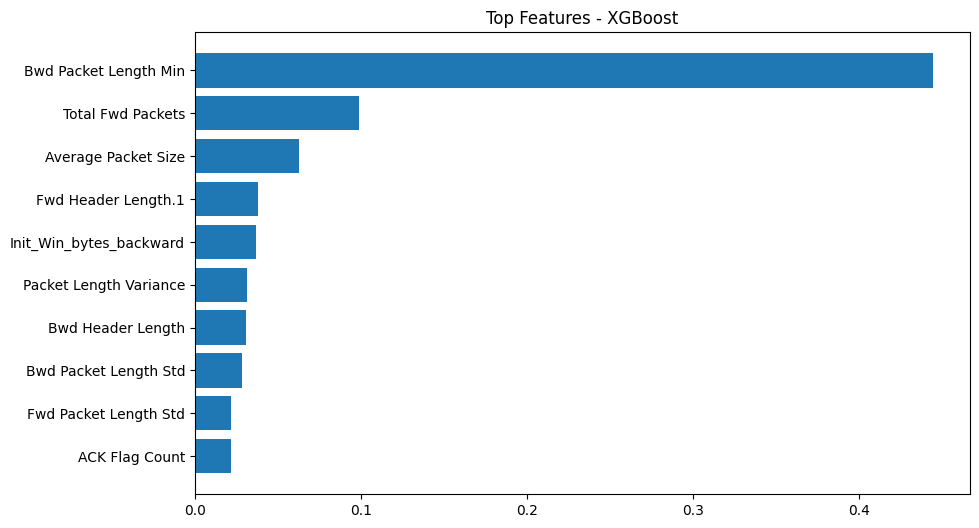

In [ ]:
import pandas as pd

feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feat_df["Feature"][:10])

plt.figure(figsize=(10,6))
plt.barh(feat_df["Feature"][:10], feat_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top Features - XGBoost")
plt.show()

### Split Features and Target (UNSW)

UNSW

data cleaning

In [ ]:
X_unsw = unsw.drop("label", axis=1)
y_unsw = unsw["label"]

from sklearn.model_selection import train_test_split

X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_unsw, y_unsw, test_size=0.2, random_state=42
)

### Identify Numeric and Categorical Columns

In [ ]:
num_cols = X_train_u.select_dtypes(include=[np.number]).columns
cat_cols = X_train_u.select_dtypes(include=['object']).columns

print("Numeric:", len(num_cols))
print("Categorical:", len(cat_cols))

Numeric: 121
Categorical: 29


### Convert Categorical Columns to String

In [ ]:
X_train_u[cat_cols] = X_train_u[cat_cols].astype(str)
X_test_u[cat_cols] = X_test_u[cat_cols].astype(str)

### Check Categorical Column Types

In [ ]:
print(X_train_u[cat_cols].dtypes.unique())

[dtype('O')]


### Impute Numerical Features

In [ ]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='mean')

X_train_num = num_imputer.fit_transform(X_train_u[num_cols])
X_test_num = num_imputer.transform(X_test_u[num_cols])

### Impute Categorical Features

In [ ]:
if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train_cat = cat_imputer.fit_transform(X_train_u[cat_cols])
    X_test_cat = cat_imputer.transform(X_test_u[cat_cols])
else:
    import numpy as np
    X_train_cat = np.empty((len(X_train_u), 0))
    X_test_cat = np.empty((len(X_test_u), 0))

### Check Shapes After Imputation

In [ ]:
print("Numeric:", X_train_num.shape)
print("Categorical:", X_train_cat.shape)

Numeric: (160000, 121)
Categorical: (160000, 29)


### Convert Imputed Categorical Data to DataFrame

In [ ]:
if len(cat_cols) > 0:
    import pandas as pd
    X_train_cat = pd.DataFrame(X_train_cat, columns=cat_cols)
    X_test_cat = pd.DataFrame(X_test_cat, columns=cat_cols)
else:
    import pandas as pd
    X_train_cat = pd.DataFrame()
    X_test_cat = pd.DataFrame()

### Encode Categorical Features

In [ ]:
if len(cat_cols) > 0:
    from sklearn.preprocessing import OrdinalEncoder
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train_cat = encoder.fit_transform(X_train_cat)
    X_test_cat = encoder.transform(X_test_cat)

### Check Encoded Categorical Features

In [ ]:
print(type(X_train_cat), X_train_cat.shape)

<class 'numpy.ndarray'> (160000, 29)


### Stack Numerical and Categorical Features

models

In [ ]:
import numpy as np
if len(cat_cols) > 0:
    X_train_u = np.hstack((X_train_num, X_train_cat))
    X_test_u = np.hstack((X_test_num, X_test_cat))
else:
    X_train_u = X_train_num
    X_test_u = X_test_num

### Apply SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_train_u, y_train_u = smote.fit_resample(X_train_u, y_train_u)

### Train Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_u = DecisionTreeClassifier(random_state=42)
dt_u.fit(X_train_u, y_train_u)

y_pred_dt_u = dt_u.predict(X_test_u)

print("UNSW Decision Tree Accuracy:", accuracy_score(y_test_u, y_pred_dt_u))
print(classification_report(y_test_u, y_pred_dt_u))

UNSW Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     37418
           1       1.00      1.00      1.00      2582

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



### Train Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_u = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    max_features='sqrt',
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_u.fit(X_train_u, y_train_u)
y_pred_rf_u = rf_u.predict(X_test_u)

print("UNSW RF Accuracy:", accuracy_score(y_test_u, y_pred_rf_u))
print(classification_report(y_test_u, y_pred_rf_u))

UNSW RF Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     37418
           1       1.00      1.00      1.00      2582

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



### Train XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb_u = XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_u.fit(X_train_u, y_train_u)
y_pred_xgb_u = xgb_u.predict(X_test_u)

print("UNSW XGB Accuracy:", accuracy_score(y_test_u, y_pred_xgb_u))
print(classification_report(y_test_u, y_pred_xgb_u))

UNSW XGB Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     37418
           1       1.00      1.00      1.00      2582

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



### Define Confusion Matrix Plot Function

Visualization

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Attack"])
    disp.plot()
    plt.title(title)
    plt.show()

### Plot Confusion Matrices

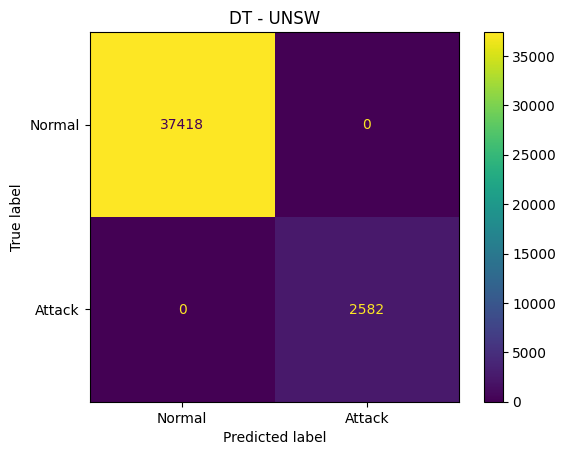

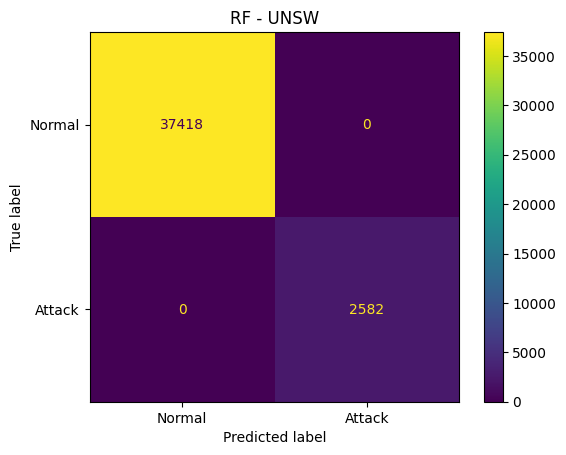

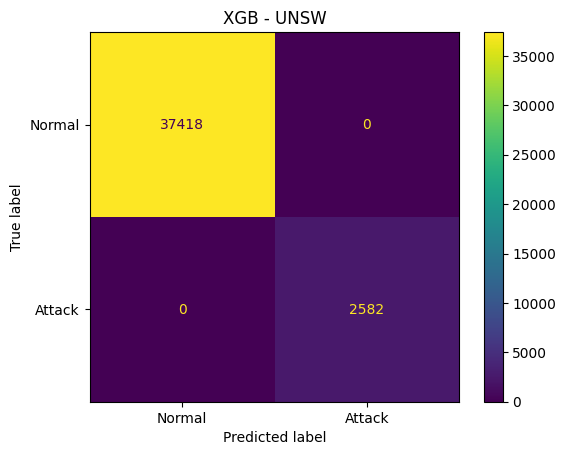

In [ ]:
plot_confusion(y_test_u, y_pred_dt_u, "DT - UNSW")
plot_confusion(y_test_u, y_pred_rf_u, "RF - UNSW")
plot_confusion(y_test_u, y_pred_xgb_u, "XGB - UNSW")

### Define Metrics Plot Function

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def plot_metrics(y_true, y_pred, title):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    metrics = ['Precision', 'Recall', 'F1']
    values = [precision, recall, f1]

    plt.figure()
    plt.bar(metrics, values)
    plt.title(title)
    plt.ylim(0,1)
    plt.show()

### Plot Performance Metrics

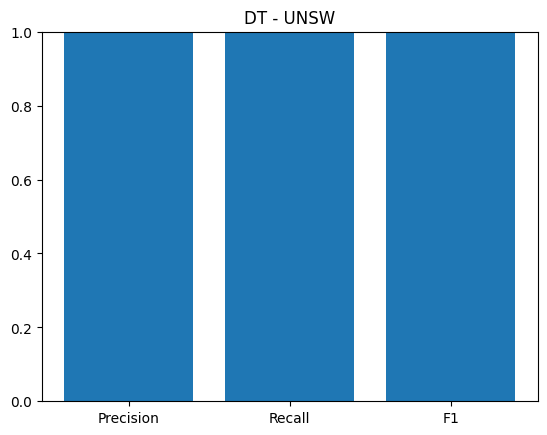

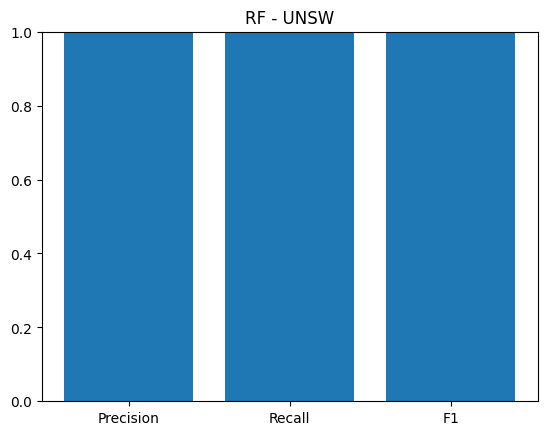

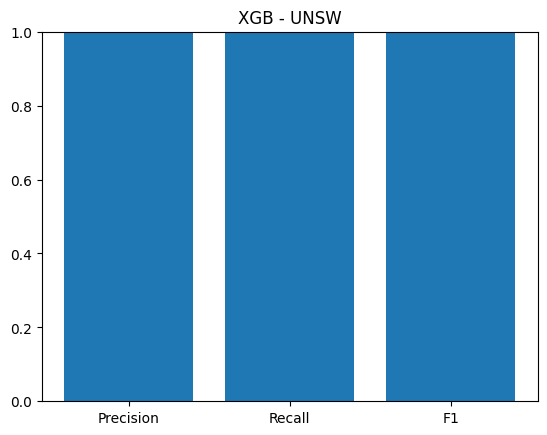

In [ ]:
plot_metrics(y_test_u, y_pred_dt_u, "DT - UNSW")
plot_metrics(y_test_u, y_pred_rf_u, "RF - UNSW")
plot_metrics(y_test_u, y_pred_xgb_u, "XGB - UNSW")

### Define Feature Importance Plot Function

In [ ]:
import pandas as pd

def plot_feature_importance(model, feature_names, title):
    importances = model.feature_importances_

    feat_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    print(feat_df["Feature"][:10])
    print(feat_df["Importance"][:10])

    plt.figure(figsize=(10,6))
    plt.barh(feat_df["Feature"][:10], feat_df["Importance"][:10])
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.show()

### Plot Feature Importances

127                     .
121    Attack subcategory
124        Destination IP
3        Destination Port
123             Source IP
23                    0.1
1               Last time
125           Attack Name
9                      29
8                      31
Name: Feature, dtype: object
127    0.164175
121    0.095038
124    0.089184
3      0.079354
123    0.071134
23     0.070387
1      0.051577
125    0.046286
9      0.042255
8      0.031417
Name: Importance, dtype: float64


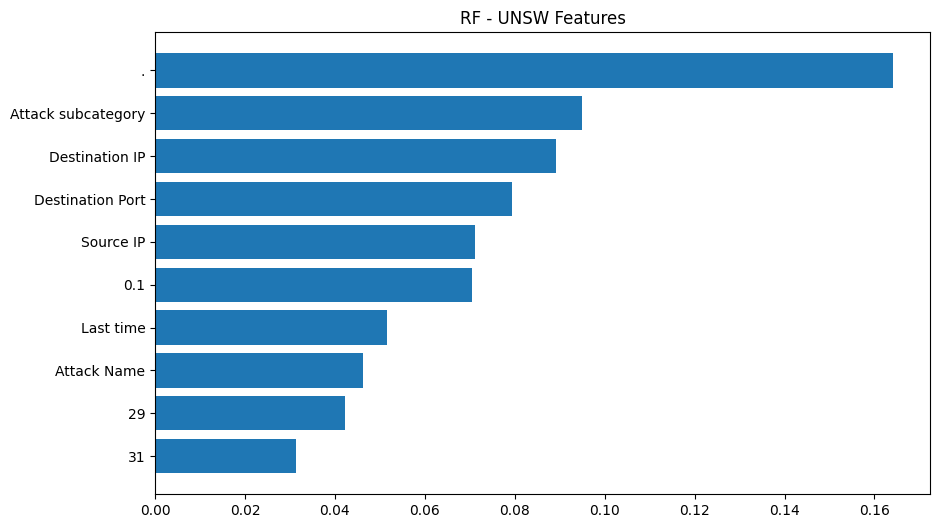

127                 .
124    Destination IP
123         Source IP
2         Source Port
0          Start time
1           Last time
6                4238
7               60788
8                  31
9                  29
Name: Feature, dtype: object
127    0.814849
124    0.108509
123    0.076641
2      0.000000
0      0.000000
1      0.000000
6      0.000000
7      0.000000
8      0.000000
9      0.000000
Name: Importance, dtype: float32


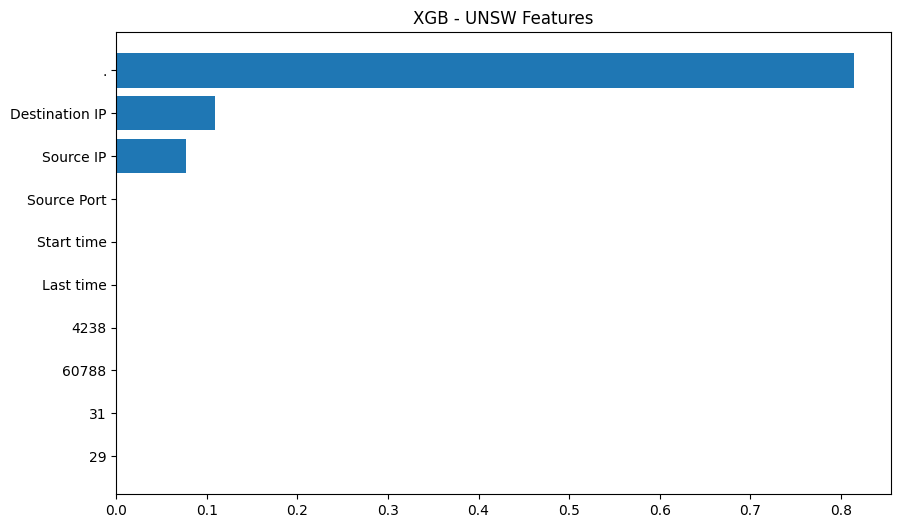

In [ ]:
feature_names = list(num_cols) + list(cat_cols)

plot_feature_importance(rf_u, feature_names, "RF - UNSW Features")
plot_feature_importance(xgb_u, feature_names, "XGB - UNSW Features")

### Define Columns to Drop (CICIDS)

CICIDS

In [ ]:
drop_cols = [
    'Destination Port',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Packet Length Variance',
    'Average Packet Size'
]

cicids_clean = cicids.drop(
    columns=[col for col in drop_cols if col in cicids.columns],
    errors='ignore'
)

### Drop Columns from CICIDS

In [ ]:
X = cicids_clean.drop("label", axis=1)
y = cicids_clean["label"]

### Split Features and Target

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Split Train/Test Data

In [ ]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.dropna()
y_train = y_train[X_train.index]

X_test = X_test.dropna()
y_test = y_test[X_test.index]

### Handle NaNs and Infs

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

### Apply SMOTE

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.997175
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     32224
           1       0.99      1.00      0.99      7776

    accuracy                           1.00     40000
   macro avg       0.99      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



### Train Random Forest

In [ ]:
drop_cols_unsw = [
    'IPV4_SRC_ADDR', 'IPV4_DST_ADDR',  # IP addresses leak environment
    'L4_SRC_PORT', 'L4_DST_PORT',      # Specific port ranges leak attack scenarios
    'Label', 'Attack'                  # Target columns
]

### Drop Columns from UNSW

In [ ]:
unsw_clean = unsw.drop(
    columns=[col for col in drop_cols_unsw if col in unsw.columns],
    errors='ignore'
)

### Split Features and Target (UNSW)

In [ ]:
X_unsw = unsw_clean.drop("label", axis=1)
y_unsw = unsw_clean["label"]

from sklearn.model_selection import train_test_split

X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_unsw, y_unsw, test_size=0.2, random_state=42
)

### Identify Numeric and Categorical Columns

In [ ]:
num_cols = X_train_u.select_dtypes(include=[np.number]).columns
cat_cols = X_train_u.select_dtypes(include=['object']).columns

X_train_u[cat_cols] = X_train_u[cat_cols].astype(str)
X_test_u[cat_cols] = X_test_u[cat_cols].astype(str)

### Impute Features

In [ ]:
from sklearn.impute import SimpleImputer
num_imputer = SimpleImputer(strategy='mean')
X_train_num = num_imputer.fit_transform(X_train_u[num_cols])
X_test_num = num_imputer.transform(X_test_u[num_cols])
if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train_cat = cat_imputer.fit_transform(X_train_u[cat_cols])
    X_test_cat = cat_imputer.transform(X_test_u[cat_cols])
else:
    import numpy as np
    X_train_cat = np.empty((len(X_train_u), 0))
    X_test_cat = np.empty((len(X_test_u), 0))

### Encode Categorical Features

In [ ]:
if len(cat_cols) > 0:
    from sklearn.preprocessing import OrdinalEncoder
    import pandas as pd
    X_train_cat = pd.DataFrame(X_train_cat, columns=cat_cols)
    X_test_cat = pd.DataFrame(X_test_cat, columns=cat_cols)
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train_cat = encoder.fit_transform(X_train_cat)
    X_test_cat = encoder.transform(X_test_cat)

### Stack Processed Features

In [ ]:
import numpy as np
if len(cat_cols) > 0:
    X_train_u = np.hstack((X_train_num, X_train_cat))
    X_test_u = np.hstack((X_test_num, X_test_cat))
else:
    X_train_u = X_train_num
    X_test_u = X_test_num

### Apply SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_train_u, y_train_u = smote.fit_resample(X_train_u, y_train_u)

### Train Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_u = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42
)

rf_u.fit(X_train_u, y_train_u)
y_pred = rf_u.predict(X_test_u)

print("UNSW Clean Accuracy:", accuracy_score(y_test_u, y_pred))
print(classification_report(y_test_u, y_pred))

UNSW Clean Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     37418
           1       1.00      1.00      1.00      2582

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



### Reload UNSW Dataset (Multi-Class)

trying multiclass again

In [ ]:
unsw = pd.read_parquet("data/Kaggle-UNSW-NB15-V2/Kaggle-UNSW-NB15-V2/NF-UNSW-NB15-V2.parquet")
unsw.columns = unsw.columns.str.strip()

print(unsw.shape)

Error loading /content/drive/MyDrive/4thSemELDatasets/UNSW-NB15/NUSW-NB15_features.csv


/tmp/ipykernel_1836/3670526034.py:7: DtypeWarning: Columns (1,3,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)
/tmp/ipykernel_1836/3670526034.py:7: DtypeWarning: Columns (3,39,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


(2714390, 151)


### Create Multi-Class Labels

In [ ]:
unsw['label'] = unsw['Attack'].fillna('Benign').astype(str).str.strip()

print(unsw['label'].value_counts())

label
Normal            2540043
Exploits            68217
Fuzzers             33638
DoS                 24582
Reconnaissance      20136
Generic             19860
Backdoor             4097
Analysis             1881
Shellcode            1511
Backdoors             256
Worms                 169
Name: count, dtype: int64


### Sample UNSW Dataset

In [ ]:
unsw = unsw.sample(n=300000, random_state=42)

print(unsw.shape)

(300000, 152)


### Encode Multi-Class Labels

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
unsw['label_encoded'] = le.fit_transform(unsw['label'])

print("Classes:", list(le.classes_))

Classes: ['Analysis', 'Backdoor', 'Backdoors', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


### Drop Original Label Columns

In [ ]:
drop_cols = [
    'Attack category',
    'Attack subcategory',
    'Attack Name',
    'Attack Reference'
]

unsw = unsw.drop(columns=[col for col in drop_cols if col in unsw.columns], errors='ignore')

### Split Features and Target

In [ ]:
X = unsw.drop(['label', 'label_encoded'], axis=1)
y = unsw['label_encoded']

### Split Train/Test Data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Separate Numeric/Categorical Columns

In [ ]:
import numpy as np

num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

print("Numeric:", len(num_cols))
print("Categorical:", len(cat_cols))

Numeric: 121
Categorical: 26


### Convert Categorical Columns to String

In [ ]:
X_train[cat_cols] = X_train[cat_cols].astype(str)
X_test[cat_cols] = X_test[cat_cols].astype(str)

### Impute Features

In [ ]:
from sklearn.impute import SimpleImputer
num_imputer = SimpleImputer(strategy='mean')
X_train_num = num_imputer.fit_transform(X_train[num_cols])
X_test_num = num_imputer.transform(X_test[num_cols])
if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train_cat = cat_imputer.fit_transform(X_train[cat_cols])
    X_test_cat = cat_imputer.transform(X_test[cat_cols])
else:
    import numpy as np
    X_train_cat = np.empty((len(X_train), 0))
    X_test_cat = np.empty((len(X_test), 0))

### Encode Categorical Features

In [ ]:
if len(cat_cols) > 0:
    import pandas as pd
    from sklearn.preprocessing import OrdinalEncoder
    X_train_cat = pd.DataFrame(X_train_cat, columns=cat_cols)
    X_test_cat = pd.DataFrame(X_test_cat, columns=cat_cols)
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train_cat = encoder.fit_transform(X_train_cat)
    X_test_cat = encoder.transform(X_test_cat)

### Stack Processed Features

In [ ]:
if len(cat_cols) > 0:
    X_train = np.hstack((X_train_num, X_train_cat))
    X_test = np.hstack((X_test_num, X_test_cat))
else:
    X_train = X_train_num
    X_test = X_test_num

decision trees

In [ ]:
dt_unsw = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

dt_unsw.fit(X_train, y_train)

y_pred_dt_unsw = dt_unsw.predict(X_test)

print("UNSW DT Accuracy:", accuracy_score(y_test, y_pred_dt_unsw))

print(classification_report(
    y_test,
    y_pred_dt_unsw,
    target_names=le.classes_
))

UNSW DT Accuracy: 0.9437166666666666
                precision    recall  f1-score   support

      Analysis       0.01      0.12      0.03        43
      Backdoor       0.05      0.94      0.09        90
     Backdoors       0.11      1.00      0.19         4
           DoS       0.00      0.00      0.00       542
      Exploits       0.00      0.00      0.00      1501
       Fuzzers       0.33      0.08      0.12       741
       Generic       0.97      0.60      0.74       431
        Normal       1.00      1.00      1.00     56179
Reconnaissance       0.00      0.00      0.00       431
     Shellcode       0.22      0.91      0.36        34
         Worms       0.00      0.75      0.01         4

      accuracy                           0.94     60000
     macro avg       0.24      0.49      0.23     60000
  weighted avg       0.95      0.94      0.94     60000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from sklearn.tree import plot_tree

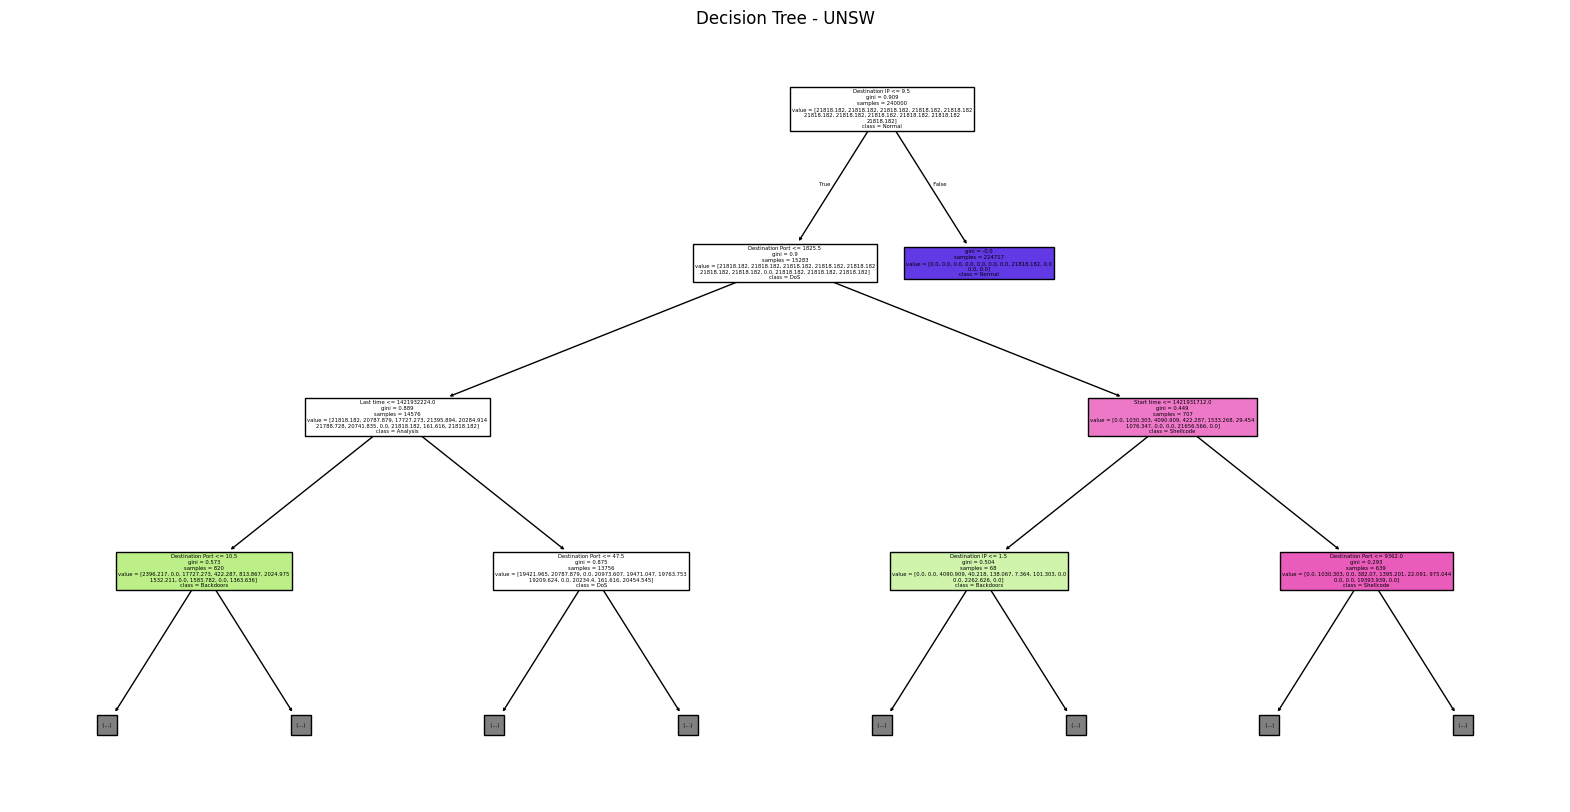

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    dt_unsw,
    feature_names=list(num_cols) + list(cat_cols),
    class_names=le.classes_,
    filled=True,
    max_depth=3
)

plt.title("Decision Tree - UNSW")
plt.show()

### Train Random Forest (Initial)

random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.97395
                precision    recall  f1-score   support

      Analysis       0.00      0.00      0.00        43
      Backdoor       0.00      0.00      0.00        90
     Backdoors       0.00      0.00      0.00         4
           DoS       0.20      0.00      0.00       542
      Exploits       0.50      0.97      0.66      1501
       Fuzzers       0.80      0.52      0.63       741
       Generic       0.98      0.65      0.78       431
        Normal       1.00      1.00      1.00     56179
Reconnaissance       0.90      0.31      0.46       431
     Shellcode       1.00      0.03      0.06        34
         Worms       0.00      0.00      0.00         4

      accuracy                           0.97     60000
     macro avg       0.49      0.32      0.33     60000
  weighted avg       0.97      0.97      0.97     60000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Plot Multi-Class Confusion Matrix

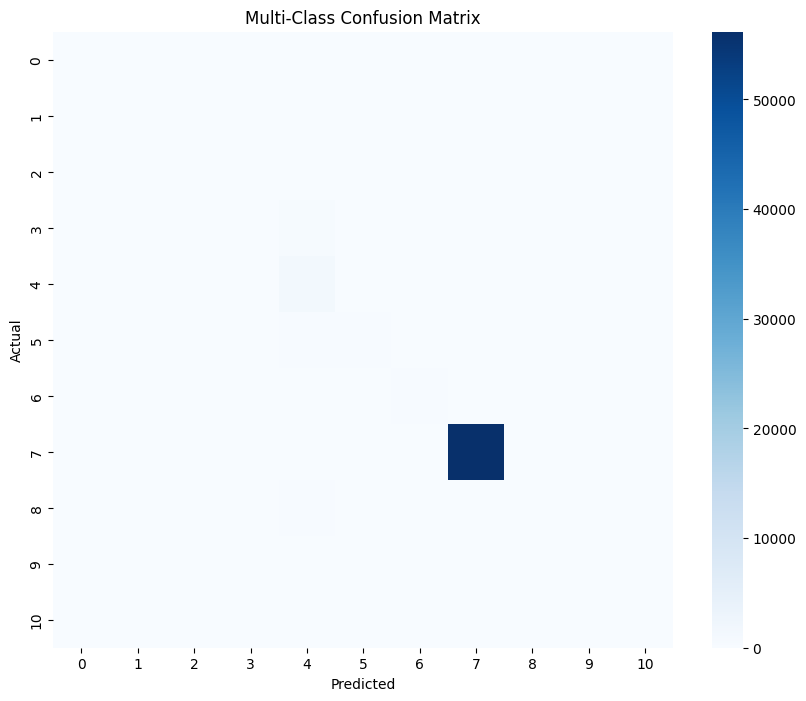

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap='Blues')
plt.title("Multi-Class Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Train Random Forest with Class Weight

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced',   # 🔥 KEY FIX
    n_jobs=-1,
    random_state=42
)

### Evaluate RF with Class Weight

In [ ]:
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9632
                precision    recall  f1-score   support

      Analysis       0.06      0.30      0.10        43
      Backdoor       0.06      0.56      0.11        90
     Backdoors       0.10      0.25      0.14         4
           DoS       0.26      0.37      0.30       542
      Exploits       0.68      0.27      0.39      1501
       Fuzzers       0.78      0.56      0.65       741
       Generic       0.97      0.66      0.78       431
        Normal       1.00      1.00      1.00     56179
Reconnaissance       0.52      0.49      0.51       431
     Shellcode       0.33      0.74      0.45        34
         Worms       0.00      0.00      0.00         4

      accuracy                           0.96     60000
     macro avg       0.43      0.47      0.40     60000
  weighted avg       0.98      0.96      0.97     60000



### Plot Recall per Class

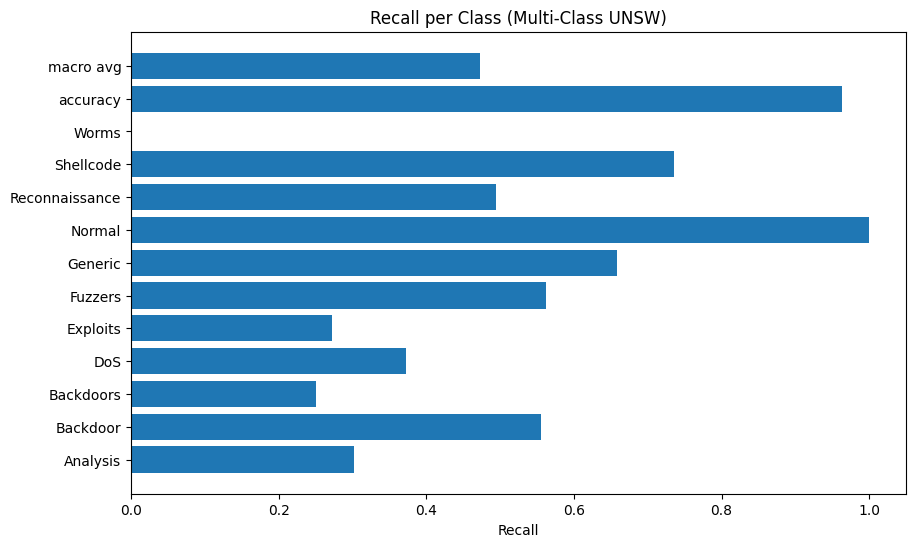

In [ ]:
report = classification_report(
    y_test,
    y_pred,
    target_names=le.classes_,
    output_dict=True
)

import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(report).transpose()

plt.figure(figsize=(10,6))
plt.barh(df.index[:-1], df['recall'][:-1])
plt.title("Recall per Class (Multi-Class UNSW)")
plt.xlabel("Recall")
plt.show()

### Train Multi-Class XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGB Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

XGB Accuracy: 0.97355
                precision    recall  f1-score   support

      Analysis       0.50      0.09      0.16        43
      Backdoor       0.00      0.00      0.00        90
     Backdoors       0.00      0.00      0.00         4
           DoS       0.24      0.06      0.10       542
      Exploits       0.51      0.88      0.65      1501
       Fuzzers       0.81      0.54      0.65       741
       Generic       0.95      0.66      0.78       431
        Normal       1.00      1.00      1.00     56179
Reconnaissance       0.71      0.42      0.53       431
     Shellcode       0.39      0.35      0.37        34
         Worms       0.00      0.00      0.00         4

      accuracy                           0.97     60000
     macro avg       0.46      0.36      0.38     60000
  weighted avg       0.97      0.97      0.97     60000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Train Multi-Class Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, n_jobs=-1)

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

KeyboardInterrupt: 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# SCALE
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MODEL - Removed multi_class='multinomial' for scikit-learn compatibility
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("UNSW LR Accuracy:", accuracy_score(y_test, y_pred_lr))

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=le.classes_
))

### Reload CICIDS Dataset (Multi-Class)

multiclass on cicids

In [ ]:
cicids = load_dataset("data/CIC-IDS-2017/CIC-IDS-2017")

### Inspect CICIDS Labels

In [ ]:
cicids.columns = cicids.columns.str.strip()
print(cicids.columns.tolist())
print([col for col in cicids.columns if "label" in col.lower()])
print(cicids['Label'].unique()[:10])
print(cicids['Label'].value_counts().head(20))

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

### Encode Multi-Class Labels

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_cic = LabelEncoder()

cicids['label_mc'] = le_cic.fit_transform(cicids['Label'])

print(le_cic.classes_)

['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack � Brute Force' 'Web Attack � Sql Injection'
 'Web Attack � XSS']


### Sample CICIDS and Split Features/Target

In [ ]:
X_cic = cicids.drop(['Label', 'label_mc'], axis=1)
y_cic = cicids['label_mc']

In [ ]:
cicids_sample = cicids.sample(n=300000, random_state=42)

X_cic = cicids_sample.drop(['Label', 'label_mc'], axis=1)
y_cic = cicids_sample['label_mc']

### Split Train/Test Data

In [ ]:
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cic, y_cic,
    test_size=0.2,
    random_state=42,
    stratify=y_cic
)

### Handle NaNs and Infs

In [ ]:
import numpy as np

X_train_c = X_train_c.replace([np.inf, -np.inf], np.nan)
X_test_c = X_test_c.replace([np.inf, -np.inf], np.nan)

X_train_c = X_train_c.dropna()
y_train_c = y_train_c[X_train_c.index]

X_test_c = X_test_c.dropna()
y_test_c = y_test_c[X_test_c.index]

### Train Multi-Class Random Forest

decision trees

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

dt_cic = DecisionTreeClassifier(
    max_depth=5,   # 🔥 IMPORTANT: keep small for visualization
    random_state=42
)

dt_cic.fit(X_train_c, y_train_c)

y_pred_dt_cic = dt_cic.predict(X_test_c)

print("CICIDS DT Accuracy:", accuracy_score(y_test_c, y_pred_dt_cic))

print(classification_report(
    y_test_c,
    y_pred_dt_cic,
    labels=np.unique(y_test_c),
    target_names=le_cic.classes_[np.unique(y_test_c)]
))

CICIDS DT Accuracy: 0.9649482816149483
                          precision    recall  f1-score   support

                  BENIGN       0.99      0.97      0.98     48142
                     Bot       0.00      0.00      0.00        41
                    DDoS       1.00      0.99      1.00      2723
           DoS GoldenEye       1.00      0.62      0.77       217
                DoS Hulk       0.74      0.99      0.84      4878
        DoS Slowhttptest       0.90      0.16      0.27       113
           DoS slowloris       0.90      0.30      0.45       124
             FTP-Patator       0.99      0.98      0.98       175
            Infiltration       0.00      0.00      0.00         1
                PortScan       0.99      0.99      0.99      3363
             SSH-Patator       0.00      0.00      0.00       121
Web Attack � Brute Force       0.00      0.00      0.00        30
        Web Attack � XSS       0.00      0.00      0.00        12

                accuracy           

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


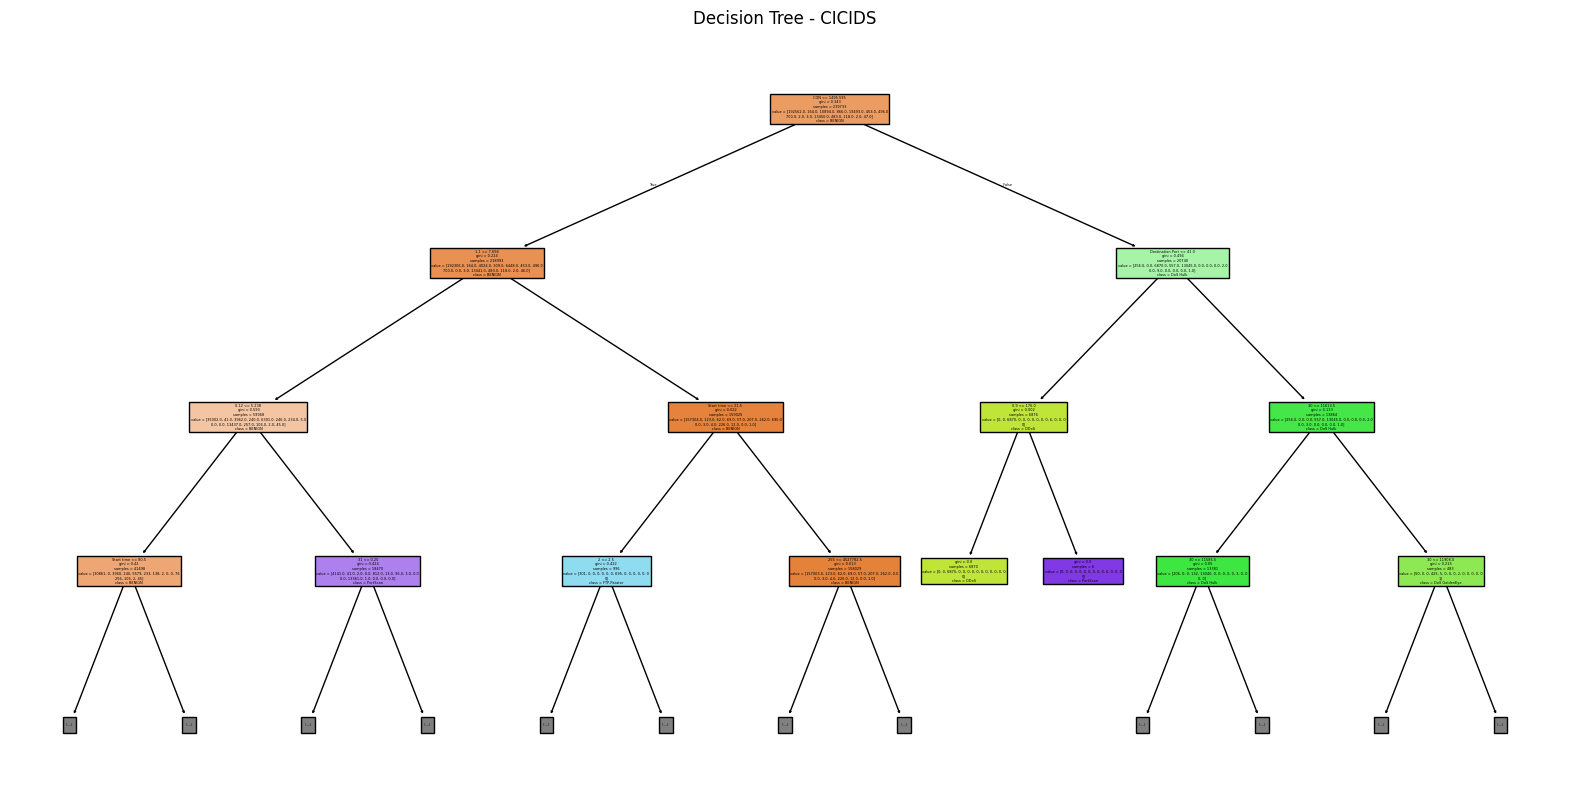

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    dt_cic,
    feature_names=X.columns,   # or your feature list
    class_names=le_cic.classes_,
    filled=True,
    max_depth=3   # 🔥 limit for readability
)

plt.title("Decision Tree - CICIDS")
plt.show()

random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf_cic_mc = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced',   # 🔥 important
    n_jobs=-1,
    random_state=42
)

rf_cic_mc.fit(X_train_c, y_train_c)

y_pred_cic = rf_cic_mc.predict(X_test_c)

print("Accuracy:", accuracy_score(y_test_c, y_pred_cic))
print(classification_report(y_test_c, y_pred_cic, target_names=le_cic.classes_))

Accuracy: 0.9867534200867534


ValueError: Number of classes, 13, does not match size of target_names, 15. Try specifying the labels parameter

### Print Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_c,
    y_pred_cic,
    labels=np.unique(y_test_c),
    target_names=le_cic.classes_[np.unique(y_test_c)]
))

                          precision    recall  f1-score   support

                  BENIGN       1.00      0.98      0.99     48142
                     Bot       0.11      0.98      0.19        41
                    DDoS       1.00      1.00      1.00      2723
           DoS GoldenEye       0.99      0.99      0.99       217
                DoS Hulk       0.95      1.00      0.97      4878
        DoS Slowhttptest       0.95      0.99      0.97       113
           DoS slowloris       0.99      0.99      0.99       124
             FTP-Patator       1.00      1.00      1.00       175
            Infiltration       0.00      0.00      0.00         1
                PortScan       1.00      1.00      1.00      3363
             SSH-Patator       1.00      0.99      1.00       121
Web Attack � Brute Force       0.50      0.60      0.55        30
        Web Attack � XSS       0.05      0.58      0.10        12

                accuracy                           0.99     59940
        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Train Multi-Class XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

xgb_cic = XGBClassifier(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    tree_method='hist',   # faster
    random_state=42
)

xgb_cic.fit(X_train_c, y_train_c)

y_pred_xgb_cic = xgb_cic.predict(X_test_c)

print("XGB Accuracy:", accuracy_score(y_test_c, y_pred_xgb_cic))

print(classification_report(
    y_test_c,
    y_pred_xgb_cic,
    labels=np.unique(y_test_c),
    target_names=le_cic.classes_[np.unique(y_test_c)]
))

XGB Accuracy: 0.998998998998999
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00     48142
                     Bot       0.86      0.90      0.88        41
                    DDoS       1.00      1.00      1.00      2723
           DoS GoldenEye       1.00      0.99      1.00       217
                DoS Hulk       1.00      1.00      1.00      4878
        DoS Slowhttptest       0.99      1.00      1.00       113
           DoS slowloris       1.00      1.00      1.00       124
             FTP-Patator       1.00      1.00      1.00       175
            Infiltration       0.00      0.00      0.00         1
                PortScan       1.00      1.00      1.00      3363
             SSH-Patator       1.00      1.00      1.00       121
Web Attack � Brute Force       0.77      0.77      0.77        30
        Web Attack � XSS       0.42      0.42      0.42        12

                accuracy                  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# DNN

In [ ]:
!pip install tensorflow

In [ ]:
!pip install tensorflow-addons

ERROR: Could not find a version that satisfies the requirement tensorflow-addons (from versions: none)
ERROR: No matching distribution found for tensorflow-addons


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
unsw = pd.read_parquet("data/Kaggle-UNSW-NB15-V2/Kaggle-UNSW-NB15-V2/NF-UNSW-NB15-V2.parquet")

Error loading /content/drive/MyDrive/4thSemELDatasets/UNSW-NB15/NUSW-NB15_features.csv


/tmp/ipykernel_18701/3670526034.py:7: DtypeWarning: Columns (1,3,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)
/tmp/ipykernel_18701/3670526034.py:7: DtypeWarning: Columns (3,39,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


## Data cleaning for UNSW

In [ ]:
unsw.columns = unsw.columns.str.strip()

print(unsw.shape)
unsw['label'] = unsw['Attack category'].fillna('Normal').astype(str).str.strip()

print(unsw['label'].value_counts())

unsw = unsw.sample(n=300000, random_state=42)

print(unsw.shape)

(2714390, 151)
label
Normal            2540043
Exploits            68217
Fuzzers             33638
DoS                 24582
Reconnaissance      20136
Generic             19860
Backdoor             4097
Analysis             1881
Shellcode            1511
Backdoors             256
Worms                 169
Name: count, dtype: int64
(300000, 152)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
unsw['label_encoded'] = le.fit_transform(unsw['label'])

print("Classes:", list(le.classes_))
drop_cols = [
    'Attack category',
    'Attack subcategory',
    'Attack Name',
    'Attack Reference'
]

unsw = unsw.drop(columns=[col for col in drop_cols if col in unsw.columns], errors='ignore')
X = unsw.drop(['label', 'label_encoded'], axis=1)
y = unsw['label_encoded']

Classes: ['Analysis', 'Backdoor', 'Backdoors', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
import numpy as np

num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

print("Numeric:", len(num_cols))
print("Categorical:", len(cat_cols))


X_train[cat_cols] = X_train[cat_cols].astype(str)
X_test[cat_cols] = X_test[cat_cols].astype(str)

Numeric: 121
Categorical: 26


In [ ]:
from sklearn.impute import SimpleImputer
# Numeric
num_imputer = SimpleImputer(strategy='mean')
X_train_num = num_imputer.fit_transform(X_train[num_cols])
X_test_num = num_imputer.transform(X_test[num_cols])
# Categorical
if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train_cat = cat_imputer.fit_transform(X_train[cat_cols])
    X_test_cat = cat_imputer.transform(X_test[cat_cols])
    import pandas as pd
    from sklearn.preprocessing import OrdinalEncoder
    X_train_cat = pd.DataFrame(X_train_cat, columns=cat_cols)
    X_test_cat = pd.DataFrame(X_test_cat, columns=cat_cols)
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train_cat = encoder.fit_transform(X_train_cat)
    X_test_cat = encoder.transform(X_test_cat)
    X_train = np.hstack((X_train_num, X_train_cat))
    X_test = np.hstack((X_test_num, X_test_cat))
else:
    X_train = X_train_num
    X_test = X_test_num

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_unsw = StandardScaler()

X_train_scaled = scaler_unsw.fit_transform(X_train)
X_test_scaled = scaler_unsw.transform(X_test)

## Data Cleaning on CICIDS

In [ ]:
cicids.columns = cicids.columns.str.strip()
print(cicids.columns.tolist())
print([col for col in cicids.columns if "label" in col.lower()])
print(cicids['Label'].unique()[:10])
print(cicids['Label'].value_counts().head(20))
from sklearn.preprocessing import LabelEncoder

le_cic = LabelEncoder()

cicids['label_mc'] = le_cic.fit_transform(cicids['Label'])

print(le_cic.classes_)

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [ ]:
X_cic = cicids.drop(['Label', 'label_mc'], axis=1)
y_cic = cicids['label_mc']
cicids_sample = cicids.sample(n=300000, random_state=42)

X_cic = cicids_sample.drop(['Label', 'label_mc'], axis=1)
y_cic = cicids_sample['label_mc']

In [ ]:
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cic,
    y_cic,
    test_size=0.2,
    random_state=42,
    stratify=y_cic
)
import numpy as np

X_train_c = X_train_c.replace([np.inf, -np.inf], np.nan)
X_test_c = X_test_c.replace([np.inf, -np.inf], np.nan)

X_train_c = X_train_c.dropna()
y_train_c = y_train_c[X_train_c.index]

X_test_c = X_test_c.dropna()
y_test_c = y_test_c[X_test_c.index]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_cic = StandardScaler()

X_train_c_scaled = scaler_cic.fit_transform(X_train_c)
X_test_c_scaled = scaler_cic.transform(X_test_c)

##DNN

In [ ]:
print(X_train_scaled.shape)
print(X_train_c_scaled.shape)

(240000, 147)
(239733, 78)


In [ ]:
unsw_model = keras.Sequential([

    keras.Input(shape=(X_train_scaled.shape[1],)),

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(64, activation='relu'),

    layers.Dense(len(le.classes_), activation='softmax')
])

In [ ]:
unsw_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

# Convert to dict
class_weights = dict(enumerate(weights))

# CAP EXTREME WEIGHTS
for k in class_weights:
    class_weights[k] = min(class_weights[k], 50)

print(class_weights)

{0: 50, 1: 50, 2: 50, 3: np.float64(10.054461667364894), 4: np.float64(3.633335856483234), 5: np.float64(7.363544319332372), 6: np.float64(12.66290297050599), 7: np.float64(0.0970918168993971), 8: np.float64(12.670256572695598), 9: 50, 10: 50}


### brief test

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy='not majority',
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print(X_train_smote.shape)
print(y_train_smote.shape)

(2471887, 147)
(2471887,)


In [ ]:
history_unsw = unsw_model.fit(
    X_train_smote,
    y_train_smote,
    validation_split=0.2,
    epochs=30,
    batch_size=1024,
    callbacks=[early_stop, reduce_lr]
)

### back

In [ ]:
history_unsw = unsw_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=1024,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

In [ ]:
test_loss, test_acc = unsw_model.evaluate(
    X_test_scaled,
    y_test
)

print("Test Accuracy:", test_acc)

In [ ]:
y_pred_probs = unsw_model.predict(X_test_scaled)

y_pred = np.argmax(y_pred_probs, axis=1)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history_unsw.history['accuracy'], label='Train Accuracy')
plt.plot(history_unsw.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("UNSW DNN Accuracy")

plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history_unsw.history['loss'], label='Train Loss')
plt.plot(history_unsw.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("UNSW DNN Loss")

plt.legend()
plt.show()

In [ ]:
import tensorflow as tf

def focal_loss(gamma=2., alpha=0.25):

    def loss(y_true, y_pred):

        y_true = tf.cast(y_true, tf.int32)

        # one-hot encode
        y_true_onehot = tf.one_hot(y_true, depth=len(le.classes_))

        # clip predictions
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

        # cross entropy
        ce = -y_true_onehot * tf.math.log(y_pred)

        # focal term
        weight = alpha * tf.pow(1 - y_pred, gamma)

        # focal loss
        fl = weight * ce

        return tf.reduce_mean(tf.reduce_sum(fl, axis=1))

    return loss

In [ ]:
unsw_model.compile(
    optimizer='adam',
    loss=focal_loss(),
    metrics=['accuracy']
)

In [ ]:
history_unsw = unsw_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=1024,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(12,12))

disp.plot(
    cmap='Blues',
    xticks_rotation='vertical',
    ax=ax
)

plt.title("UNSW DNN Confusion Matrix")
plt.show()

In [ ]:
!pip install imbalanced-learn